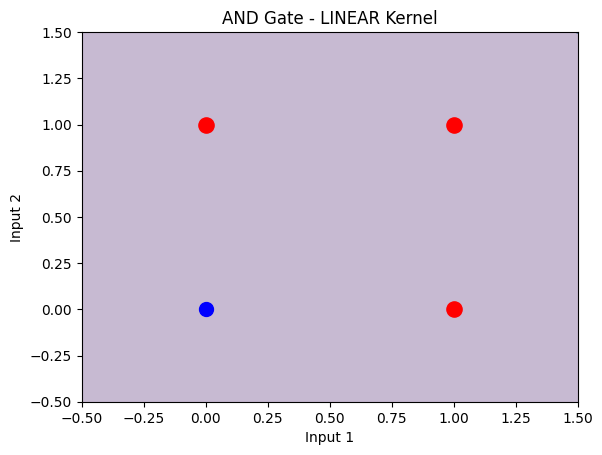

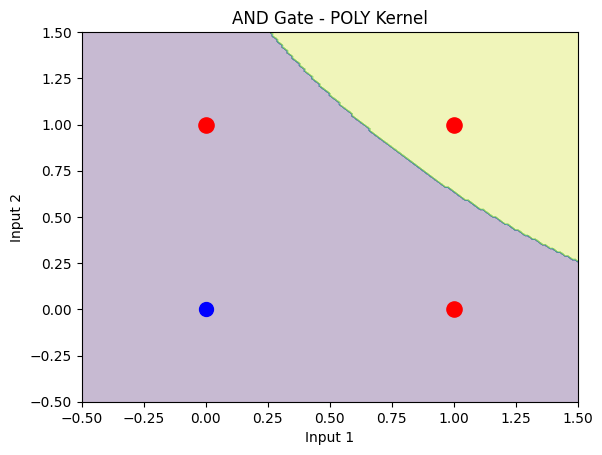

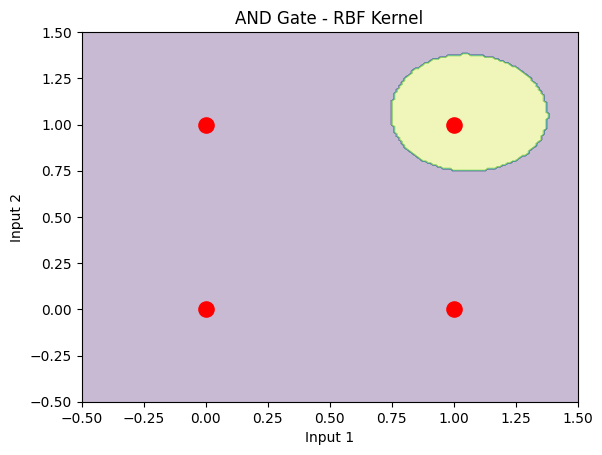

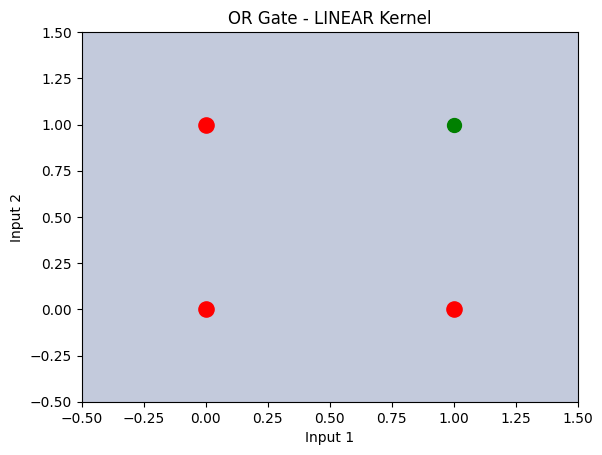

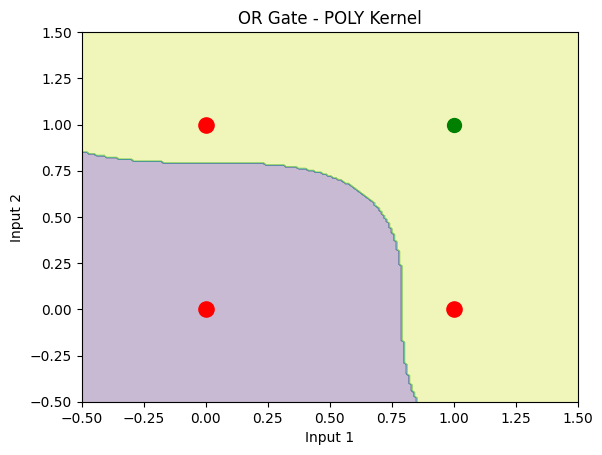

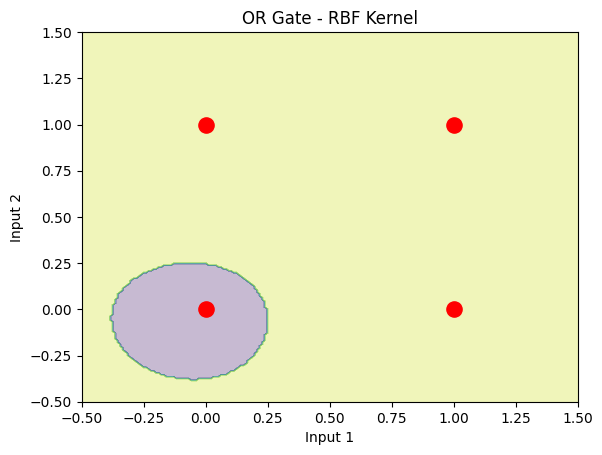

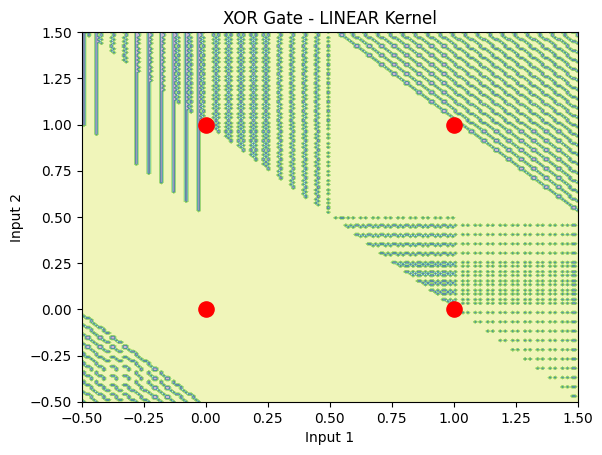

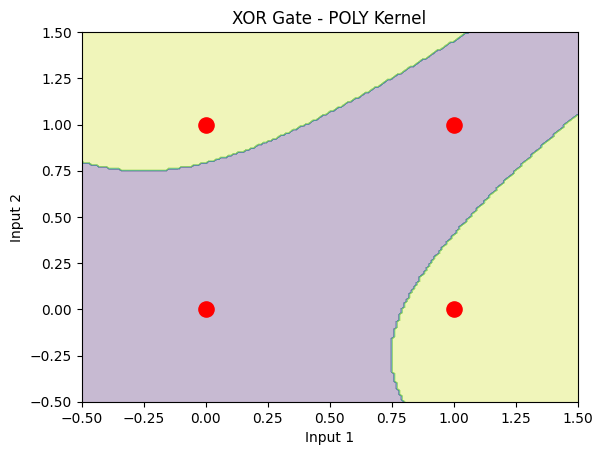

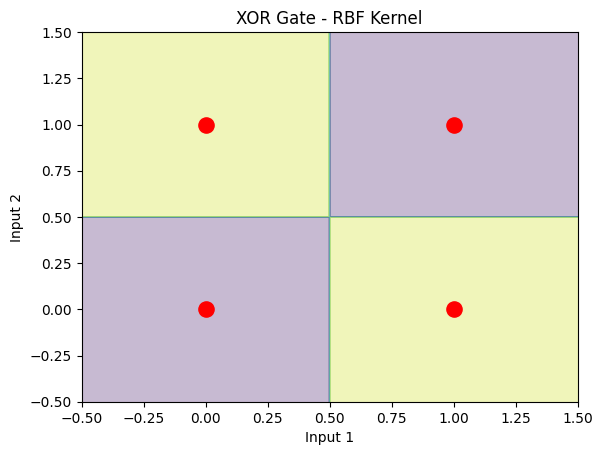


Result Table:

  GATE  Kernel Linearly separable (Y/N)
0  AND  linear                        N
1  AND    poly                        Y
2  AND     rbf                        Y
3   OR  linear                        N
4   OR    poly                        Y
5   OR     rbf                        Y
6  XOR  linear                        N
7  XOR    poly                        Y
8  XOR     rbf                        Y


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
import pandas as pd

# Input dataset (same for all gates)
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# Outputs for gates
gates = {
    "AND": np.array([0,0,0,1]),
    "OR":  np.array([0,1,1,1]),
    "XOR": np.array([0,1,1,0])
}

# Kernels to test
kernels = ["linear", "poly", "rbf"]

results = []

# Function to plot decision boundary
def plot_decision_boundary(clf, X, y, title):

    plt.figure()

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot points
    for i in range(len(X)):
        if i in clf.support_:
            plt.scatter(X[i][0], X[i][1], c="red", s=120)
        else:
            if y[i] == 0:
                plt.scatter(X[i][0], X[i][1], c="blue", s=100)
            else:
                plt.scatter(X[i][0], X[i][1], c="green", s=100)

    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()


# Train SVM for each gate and kernel
for gate_name, y in gates.items():

    for kernel in kernels:

        clf = svm.SVC(kernel=kernel, degree=3)
        clf.fit(X, y)

        pred = clf.predict(X)

        # Check if perfectly classified
        separable = "Y" if np.array_equal(pred, y) else "N"

        results.append([gate_name, kernel, separable])

        plot_decision_boundary(
            clf, X, y,
            f"{gate_name} Gate - {kernel.upper()} Kernel"
        )

# Display result table
df = pd.DataFrame(results, columns=[
    "GATE", "Kernel", "Linearly separable (Y/N)"
])

print("\nResult Table:\n")
print(df)
